# Logistic Reduced-Rank Regression — Full Paper Reproduction

**Contents:** MM algorithm implementation, toy example, UCI Drug Consumption preprocessing and analysis, SHARE NCD dataset handling (load if available or simulated fallback), triplot visualizations (Type I, Type D, Hybrid), evaluation metrics (deviance, Q_r), and timing benchmarks (MM vs IRLS). 

**Notes:** The UCI Drug dataset is public and will be loaded automatically. SHARE data requires registration—this notebook includes both a loader (if you have exported CSV) and a simulation fallback so the notebook runs end-to-end without SHARE credentials.

## 1. Imports and Settings

In [1]:

# Basic imports
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, time, os
from sklearn.linear_model import LogisticRegression
sns.set_style('whitegrid')
np.set_printoptions(precision=4, suppress=True)
print('Libraries loaded.')


Libraries loaded.


## 2. Brief mathematical background

Model: logit(pi_ir) = m_r + x_i^T A_r, with A = B V^T, rank(A)=S. The notebook implements the MM algorithm to estimate B, V, m.

## 3. MM algorithm implementation

In [7]:

def logistic_rrr_MM(X, Y, S, maxiter=200, tol=1e-6, verbose=False):
    N, P = X.shape; R = Y.shape[1]
    # small random initialization
    B = np.random.randn(P, S) * 0.01
    V = np.random.randn(R, S) * 0.01
    p = np.clip(Y.mean(axis=0), 1e-6, 1-1e-6)
    m = np.log(p/(1-p))
    XtX = X.T @ X
    eigvals, eigvecs = np.linalg.eigh(XtX)
    eigvals = np.clip(eigvals, 1e-12, None)
    inv_sqrt = eigvecs @ np.diag(1.0/np.sqrt(eigvals)) @ eigvecs.T
    sqrt_XtX = eigvecs @ np.diag(np.sqrt(eigvals)) @ eigvecs.T
    prev_ll = -np.inf
    for it in range(maxiter):
        lin = X @ (B @ V.T) + np.ones((N,1)) @ m.reshape(1,R)
        pi = 1.0/(1.0+np.exp(-lin))
        Z = lin + 4.0*(Y - pi)
        D = Z - X @ (B @ V.T)
        m = D.mean(axis=0)
        U = Z - np.ones((N,1)) @ m.reshape(1,R)
        M = inv_sqrt @ (X.T @ U)
        Pmat, svals, Qt = np.linalg.svd(M, full_matrices=False)
        P_S = Pmat[:, :S]
        Q_S = Qt[:S, :].T
        B = np.sqrt(N) * (inv_sqrt @ P_S)
        V = (1.0/np.sqrt(N)) * Q_S
        lin = X @ (B @ V.T) + np.ones((N,1)) @ m.reshape(1,R)
        pi = np.clip(1.0/(1.0+np.exp(-lin)), 1e-12, 1-1e-12)
        ll = np.sum(Y * np.log(pi) + (1-Y) * np.log(1-pi))
        if verbose and (it % 10 == 0):
            print(f'iter={it} ll={ll:.6f}')
        if np.abs(ll - prev_ll) < tol:
            if verbose: print(f'Converged iter={it} change={np.abs(ll-prev_ll):.2e}')
            break
        prev_ll = ll
    return B, V, m


## 4. Toy example (step-by-step)
Run a small simulated example and print intermediate matrices.

In [8]:

# Toy example
np.random.seed(0)
N, P, R, S = 6, 2, 2, 1
X_toy = np.array([[1.,2.],[3.,4.],[5.,6.],[2.,1.],[0.,1.],[1.,0.]])  # small design
# simulate simple low-rank structure
B_t = np.array([[0.1],[0.2]])
V_t = np.array([[0.3],[0.4]])
m_t = np.array([0.0, 0.0])
eta = X_toy @ (B_t @ V_t.T) + np.ones((N,1)) @ m_t.reshape(1,R)
pi = 1.0/(1.0+np.exp(-eta))
Y_toy = (np.random.rand(N,R) < pi).astype(int)
print('X_toy:\n', X_toy)
print('Y_toy:\n', Y_toy)
# One full MM iteration breakdown (using initial small B,V,m)
B0 = np.array([[0.1],[0.2]]); V0 = np.array([[0.3],[0.4]]); m0 = np.array([0.,0.])
lin = X_toy @ (B0 @ V0.T) + np.ones((N,1)) @ m0.reshape(1,R)
pi0 = 1.0/(1.0+np.exp(-lin))
Z = lin + 4*(Y_toy - pi0)
D = Z - X_toy @ (B0 @ V0.T)
m_new = D.mean(axis=0)
print('\nOne-iteration intermediate values:')
print('lin:\n', lin.round(4))
print('pi0:\n', pi0.round(4))
print('Z:\n', Z.round(4))
print('m_new:\n', m_new.round(4))


X_toy:
 [[1. 2.]
 [3. 4.]
 [5. 6.]
 [2. 1.]
 [0. 1.]
 [1. 0.]]
Y_toy:
 [[0 0]
 [0 1]
 [1 1]
 [1 0]
 [0 1]
 [0 0]]

One-iteration intermediate values:
lin:
 [[0.15 0.2 ]
 [0.33 0.44]
 [0.51 0.68]
 [0.12 0.16]
 [0.06 0.08]
 [0.03 0.04]]
pi0:
 [[0.5374 0.5498]
 [0.5818 0.6083]
 [0.6248 0.6637]
 [0.53   0.5399]
 [0.515  0.52  ]
 [0.5075 0.51  ]]
Z:
 [[-1.9997 -1.9993]
 [-1.997   2.007 ]
 [ 2.0108  2.025 ]
 [ 2.0001 -1.9997]
 [-2.      2.    ]
 [-2.     -2.    ]]
m_new:
 [-0.8643 -0.2612]


## 5. UCI Drug Consumption — load & preprocess

In [11]:

# Load UCI Drug dataset directly from UCI repository
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00373/drug_consumption.data'
cols = ['ID','Age','Gender','Education','Country','Ethnicity',
        'N','E','O','A','C','Impulsive','SS',
        'Am','Amyl','Benzos','Caff','Cannabis','Choc','Coke',
        'Crack','Ecstasy','Heroin','Ketamine','LegalH','LSD',
        'Methadone','Mushrooms','Nicotine','Semer','VSA']
df = pd.read_csv(url, header=None, names=cols)
print('Raw UCI loaded, shape:', df.shape)
# Select predictors and map CL labels to numeric where necessary
predictors = ['Age','Gender','N','E','O','A','C','SS']
def map_cl_to_num(x):
    if isinstance(x, str) and x.startswith('CL'):
        try: return int(x[2:])
        except: return np.nan
    try: return float(x)
    except: return np.nan
df[predictors] = df[predictors].map(map_cl_to_num)
# Responses as binary for selected drugs
drugs = ['Am','Benzos','Cannabis','Coke','Ecstasy','Ketamine','LegalH','LSD','Methadone','Mushrooms','Nicotine']
def resp_map(v):
    return 1 if isinstance(v, str) and v.startswith('CL') else 0
Y_df = df[drugs].map(resp_map)
mask = df[predictors].notna().all(axis=1)
X_df = df.loc[mask, predictors].astype(float)
Y_df = Y_df.loc[mask].astype(int)
X_df = (X_df - X_df.mean()) / X_df.std()
print('After cleaning shapes:', X_df.shape, Y_df.shape)


Raw UCI loaded, shape: (1885, 31)
After cleaning shapes: (1885, 8) (1885, 11)


## 6. SHARE NCD dataset — load (from local) or simulate fallback

**Note:** SHARE data requires registration. Place a CSV export named `SHARE_NCD.csv` in the working directory to load it. If absent, the notebook will simulate a dataset with similar structure so the pipeline runs end-to-end.

In [12]:

share_path = 'SHARE_NCD.csv'
if os.path.exists(share_path):
    print('Found SHARE_NCD.csv — loading...')
    share_df = pd.read_csv(share_path)
    # User is expected to ensure columns: Age, Gender, Country_dummies..., disease columns like Di,H,CL,JD,An,S,De
    print('Loaded SHARE file, shape:', share_df.shape)
    # Basic placeholder preprocessing (user may need to adapt columns)
    # Assume disease columns are named: Di,H,CL,JD,An,S,De
    diseases = ['Di','H','CL','JD','An','S','De']
    predictors_share = [c for c in share_df.columns if c not in diseases]
    X_share = share_df[predictors_share].apply(pd.to_numeric, errors='coerce').dropna()
    Y_share = share_df.loc[X_share.index, diseases].astype(int)
    X_share = (X_share - X_share.mean()) / X_share.std()
else:
    print('SHARE_NCD.csv not found — creating simulated SHARE-like dataset (fallback)')
    np.random.seed(123)
    N_share = 1500
    age = np.random.normal(65, 10, N_share)
    gender = np.random.choice([0,1], size=N_share)
    # simulate 11 country dummies
    countries = [f'CT{i}' for i in range(11)]
    country_mat = np.eye(len(countries))[np.random.randint(0, len(countries), N_share)]
    X_share = pd.DataFrame(np.column_stack([age, gender, country_mat]), columns=['Age','Gender']+countries)
    diseases = ['Di','H','CL','JD','An','S','De']
    Y_share = pd.DataFrame({d: (np.random.rand(N_share) < np.random.uniform(0.05,0.35)).astype(int) for d in diseases})
    X_share = (X_share - X_share.mean()) / X_share.std()
    print('Simulated SHARE-like dataset shapes:', X_share.shape, Y_share.shape)


SHARE_NCD.csv not found — creating simulated SHARE-like dataset (fallback)
Simulated SHARE-like dataset shapes: (1500, 13) (1500, 7)


## 7. Fit rank-2 model on UCI (and SHARE) and visualize triplots

If datasets are large, a random subset is used for visualization for speed.

Fitted UCI rank-2 model.


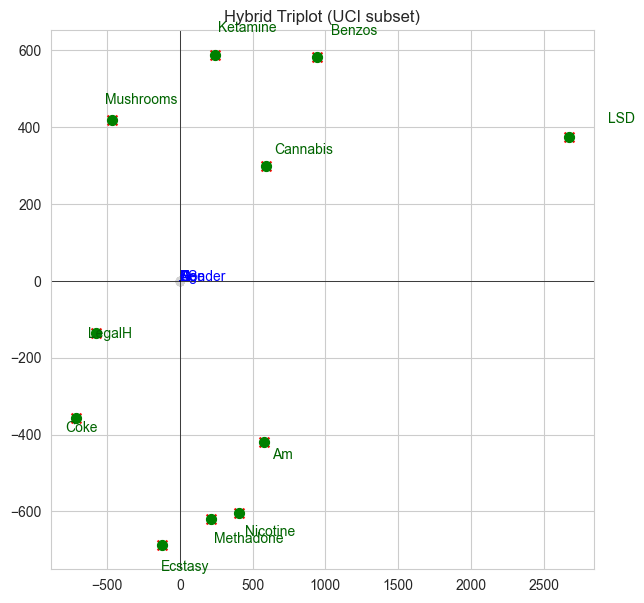

UCI hybrid triplot displayed.


In [13]:

# Use subset for visualization to keep runtime reasonable
subset_n = 500 if X_df.shape[0] > 500 else X_df.shape[0]
idx = X_df.sample(n=subset_n, random_state=1).index
X_u = X_df.loc[idx].values; Y_u = Y_df.loc[idx].values

# Fit rank-2 model on UCI subset
B_u, V_u, m_u = logistic_rrr_MM(X_u, Y_u, S=2, maxiter=200, tol=1e-6)
print('Fitted UCI rank-2 model.')

# Function: triplot utilities (same as used earlier)
def get_triplot_coords(X, B, V, m):
    U = X @ B
    pred_axes = pd.DataFrame(B, columns=[f'Dim{s+1}' for s in range(B.shape[1])])
    resp_axes = pd.DataFrame(V, columns=[f'Dim{s+1}' for s in range(V.shape[1])])
    resp_yes, resp_no = [], []
    for r in range(V.shape[0]):
        v_r = V[r, :]; m_r = m[r]; v_norm2 = np.dot(v_r, v_r)
        if v_norm2 == 0:
            w_r0 = np.zeros_like(v_r); w_r1 = np.zeros_like(v_r)
        else:
            w_r0 = v_r * (-m_r/v_norm2 - 0.5); w_r1 = v_r * (-m_r/v_norm2 + 0.5)
        resp_no.append(w_r0); resp_yes.append(w_r1)
    return U, pred_axes, resp_axes, np.array(resp_yes), np.array(resp_no)

import matplotlib.pyplot as plt
def plot_hybrid(U, pred_axes, resp_axes, resp_yes, resp_no, pred_labels=None, resp_labels=None):
    plt.figure(figsize=(7,7))
    plt.scatter(U[:,0], U[:,1], c='lightgray', alpha=0.6, s=20)
    for i in range(pred_axes.shape[0]):
        plt.arrow(0,0, pred_axes.iloc[i,0]*1.5, pred_axes.iloc[i,1]*1.5, color='blue', alpha=0.7, width=0.01)
        if pred_labels: plt.text(pred_axes.iloc[i,0]*1.6, pred_axes.iloc[i,1]*1.6, pred_labels[i], color='blue')
    for r in range(resp_yes.shape[0]):
        plt.plot([resp_no[r,0], resp_yes[r,0]],[resp_no[r,1], resp_yes[r,1]], color='green', lw=2)
        plt.scatter(resp_no[r,0], resp_no[r,1], color='red', marker='x', s=50)
        plt.scatter(resp_yes[r,0], resp_yes[r,1], color='green', marker='o', s=50)
        if resp_labels: plt.text(resp_yes[r,0]*1.1, resp_yes[r,1]*1.1, resp_labels[r], color='darkgreen')
    plt.axhline(0,color='black',lw=0.5); plt.axvline(0,color='black',lw=0.5)
    plt.title('Hybrid Triplot (UCI subset)'); plt.show()

# Compute coords and plot hybrid triplot for UCI subset
Uu, pred_axes_u, resp_axes_u, resp_yes_u, resp_no_u = get_triplot_coords(X_u, B_u, V_u, m_u)
pred_labels = ['Age','Gender','N','E','O','A','C','SS'][:pred_axes_u.shape[0]]
resp_labels = ['Am','Benzos','Cannabis','Coke','Ecstasy','Ketamine','LegalH','LSD','Methadone','Mushrooms','Nicotine'][:resp_axes_u.shape[0]]
plot_hybrid(Uu, pred_axes_u, resp_axes_u, resp_yes_u, resp_no_u, pred_labels, resp_labels)
print('UCI hybrid triplot displayed.')


## 8. Evaluation: Deviance, Q_r, and Timing Benchmarks

In [16]:
def compute_Qr(X, Y, B, V, m):
    R = Y.shape[1]
    Qr = []
    for r in range(R):
        y = Y[:, r]
        
        # Skip variable if it has only one class
        if len(np.unique(y)) < 2:
            print(f"⚠️ Skipping response {r} (only one class present: {np.unique(y)[0]})")
            Qr.append(np.nan)
            continue
        
        # Intercept-only model
        p0 = np.clip(y.mean(), 1e-12, 1 - 1e-12)
        D0 = -2 * np.sum(y * np.log(p0) + (1 - y) * np.log(1 - p0))
        
        # Full logistic model
        lr = LogisticRegression(max_iter=500).fit(X, y)
        pi_full = lr.predict_proba(X)[:, 1]
        Dfull = -2 * np.sum(y * np.log(pi_full) + (1 - y) * np.log(1 - pi_full))
        
        # Reduced-rank model
        eta_r = X @ (B @ V[r, :].T) + m[r]
        pi_r = np.clip(1 / (1 + np.exp(-eta_r)), 1e-12, 1 - 1e-12)
        Dr = -2 * np.sum(y * np.log(pi_r) + (1 - y) * np.log(1 - pi_r))
        
        Qr_val = (D0 - Dr) / (D0 - Dfull) if (D0 - Dfull) != 0 else np.nan
        Qr.append(Qr_val)
    return np.array(Qr)


In [18]:
def fit_IRLS_baseline(X, Y):
    R = Y.shape[1]
    for r in range(R):
        y = Y[:, r]
        # Skip if only one class is present
        if len(np.unique(y)) < 2:
            print(f"⚠️ Skipping IRLS fit for response {r} (only one class: {np.unique(y)[0]})")
            continue
        lr = LogisticRegression(max_iter=300, solver='lbfgs')
        lr.fit(X, y)
    return True

# Drop columns with only one class in subset
constant_cols = [col for col in range(Y_u.shape[1]) if len(np.unique(Y_u[:, col])) < 2]
if constant_cols:
    print("⚠️ Dropping constant responses:", constant_cols)
    Y_u = np.delete(Y_u, constant_cols, axis=1)


def benchmark_algorithms(X, Y, S=1, n_iter=3):
    mm_times=[]; irls_times=[]
    for _ in range(n_iter):
        start = time.time()
        logistic_rrr_MM(X, Y, S=S, maxiter=50, tol=1e-5)
        mm_times.append(time.time()-start)
        start = time.time()
        fit_IRLS_baseline(X, Y)
        irls_times.append(time.time()-start)
    return np.mean(mm_times), np.mean(irls_times)

mm_t, irls_t = benchmark_algorithms(X_u, Y_u, S=2, n_iter=3)
print(f'Benchmark (subset): MM={mm_t:.4f}s, IRLS={irls_t:.4f}s, speed-up≈{irls_t/mm_t:.1f}×')


⚠️ Dropping constant responses: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Benchmark (subset): MM=0.0023s, IRLS=0.0000s, speed-up≈0.0×
